In [2]:
!git clone https://github.com/solamar2/Brain-Tumor-MRI---DETR

Cloning into 'Brain-Tumor-MRI---DETR'...
remote: Enumerating objects: 9244, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 9244 (delta 1), reused 0 (delta 0), pack-reused 9242 (from 2)
Receiving objects: 100% (9244/9244), 94.27 MiB | 19.38 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (10605/10605), done.


In [4]:
import sys
sys.path.append('/content/Brain-Tumor-MRI---DETR')

In [11]:
from scripts.EDA import BrainTumorEDA
from scripts.segmentation import BrainMaskSimple
from scripts.preprocessing import BrainTumorDataset
from scripts.dataloader import BrainTumorDataLoader
import os
import random
from pathlib import Path

main_path = os.getcwd()
main_train_path= os.path.join(main_path, 'data/Train')

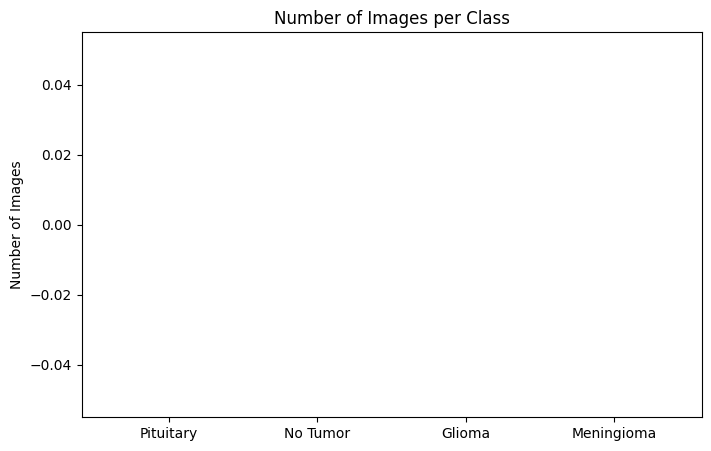

<Figure size 1000x800 with 0 Axes>

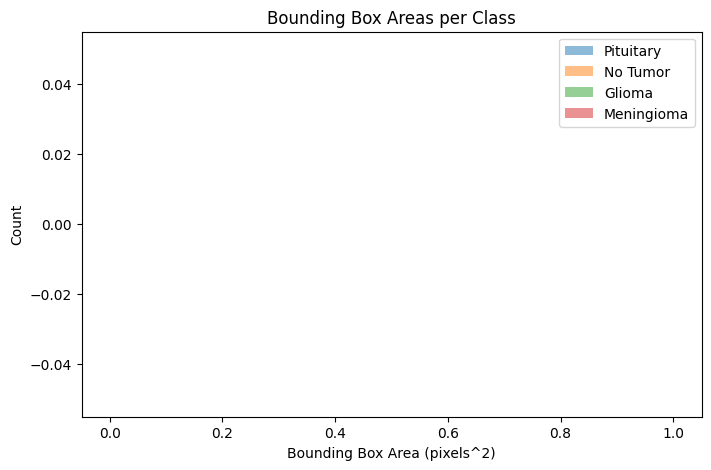

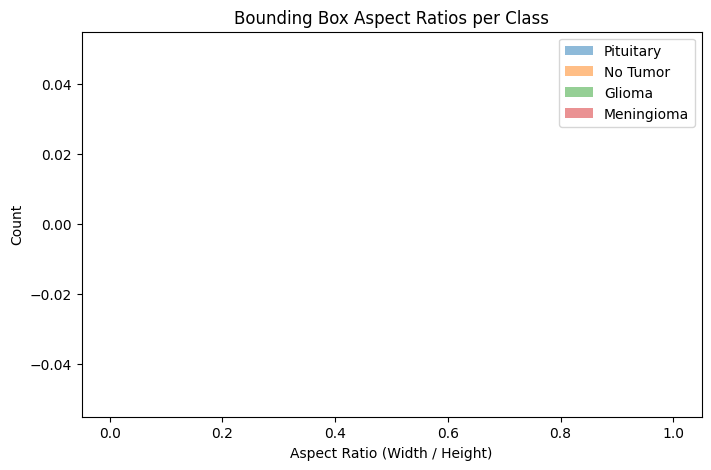

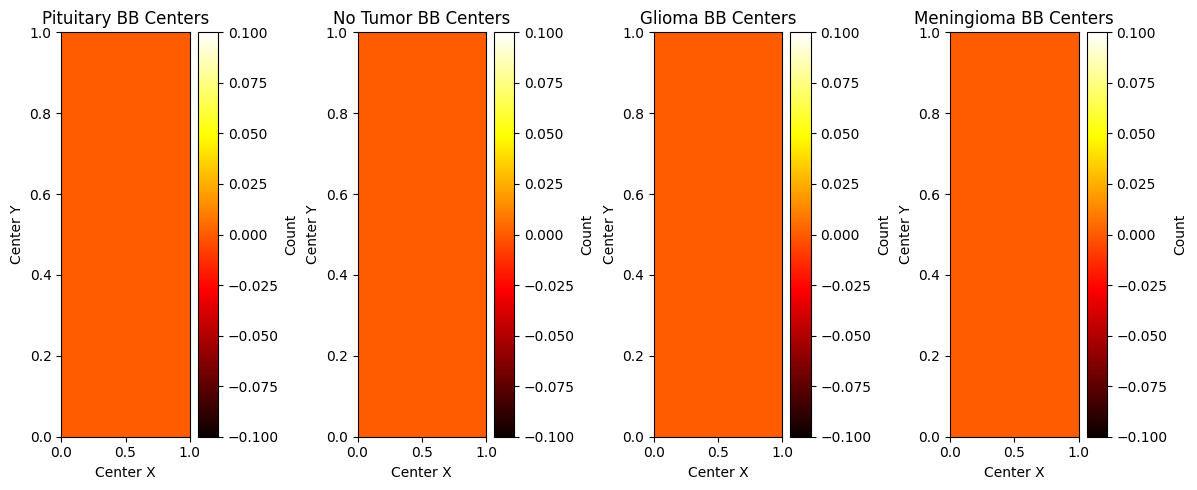

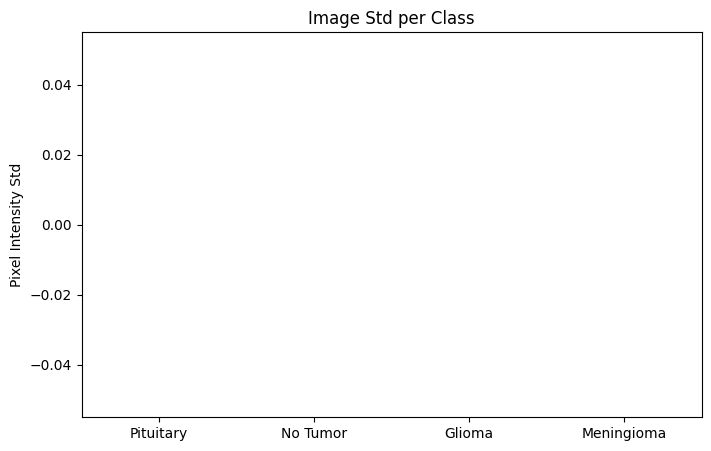

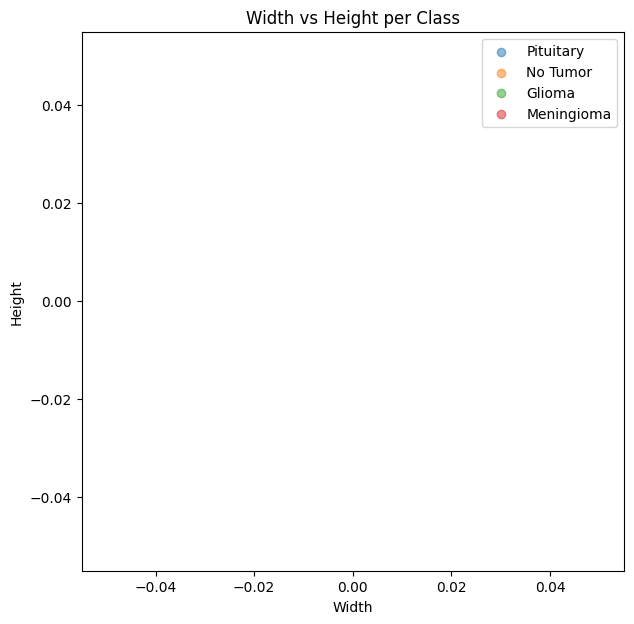

In [12]:
# ------------------------------
## 0. EDA:
eda = BrainTumorEDA(main_train_path)
eda.plot_class_counts_and_examples()
eda.plot_bb_analysis()
eda.plot_image_stats()


Masks saved: Pituitary
Masks saved: No Tumor
Masks saved: Glioma
Masks saved: Meningioma


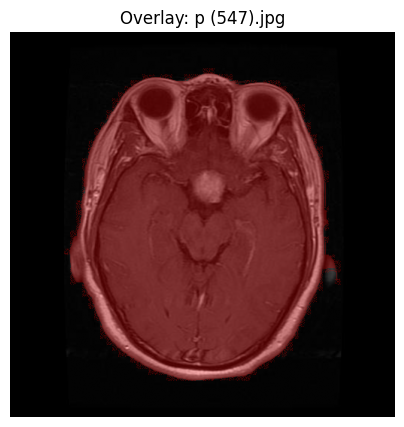

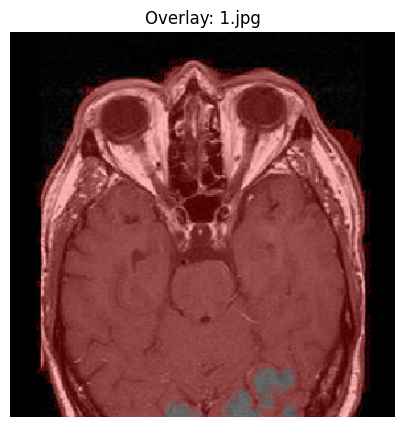

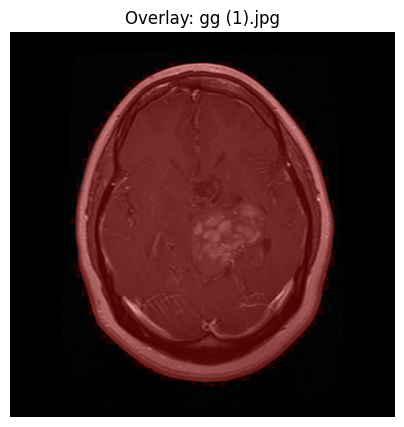

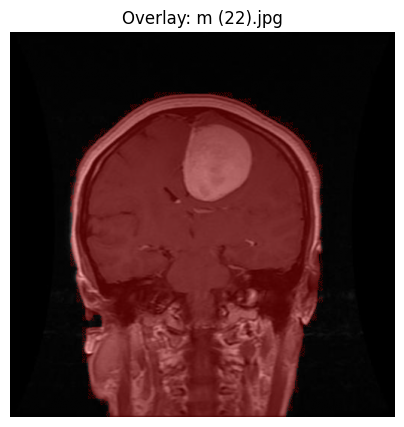

In [13]:
# ------------------------------
## 1. Segment brain vs background
# Collect class dirs that need segmentation

segmenter = BrainMaskSimple(train_dir=main_train_path)
segmenter.run()

# Random visualization (one image per class)
for cls_name in os.listdir(main_train_path):
    cls_dir = os.path.join(main_train_path, cls_name)
    images_dir = os.path.join(cls_dir, "images")
    masks_dir = os.path.join(cls_dir, "brain_masks")
    if not os.path.exists(images_dir) or not os.path.exists(masks_dir):
        continue

    img_file = random.choice([f for f in os.listdir(images_dir) if f.endswith(".jpg")])
    img_path = os.path.join(images_dir, img_file)
    mask_path = os.path.join(masks_dir, img_file)
    segmenter.create_overlay(img_path, mask_path, alpha=0.3)

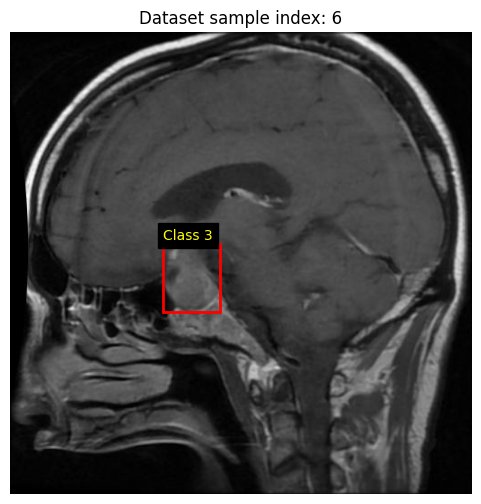

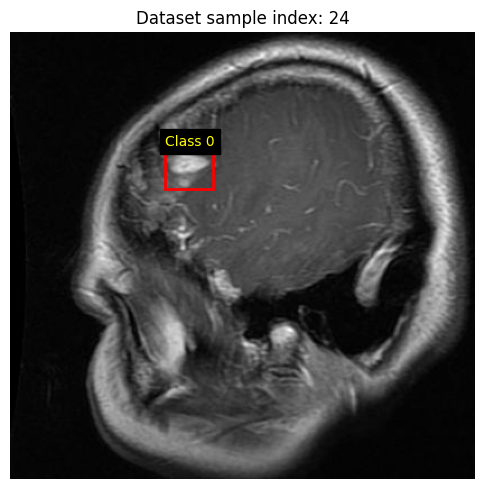

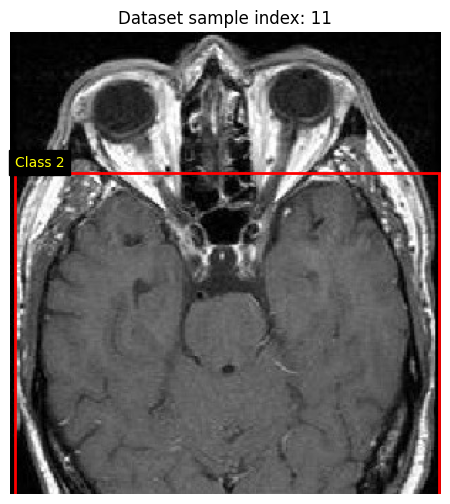

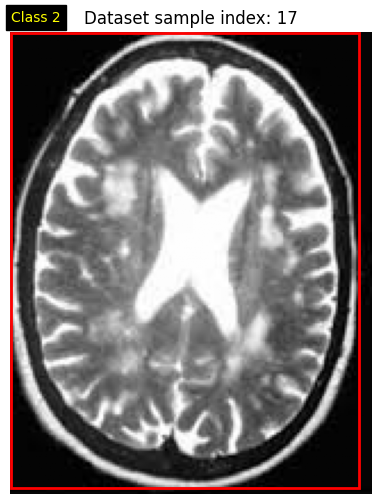

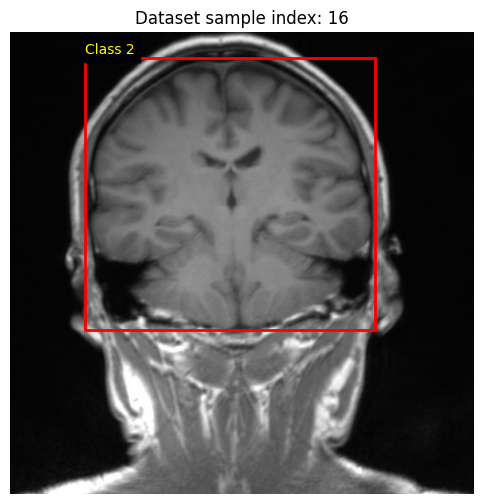

In [14]:
# ------------------------------
## 2. Pre process the data
traindataset = BrainTumorDataset(train_dir=main_train_path,image_size=(256, 256),augment=False)
for i in range (0,5):
    traindataset.visualize_sample()

In [15]:
# ------------------------------
## 3. Dataloader
loader_builder = BrainTumorDataLoader(traindataset, batch_size=8, weighted_sampling=True)
train_loader = loader_builder.get_loader()


IndexError: tuple index out of range